# 02 - Baselins & Time-Aware Train/Test Split
## Rossmann Store Sales Forecasting
The goals of this notebook are:
1. Demonstrate concretely *why* a random train/test split is wrong for forecasting (not just assert it)
2. Establish simple baselines that every later model (statistical, ML) needs to actually beat to justify its added complexity</br>

**Recap from EDA:**
- StateHoliday's mixed type quirk confirmed
- Closed-day sales confirmed geniunely 0 (172,817 rows, 17% of data, excluded via filter_closed_days())
- Strong promo effect: \\$5,929 -> \\$8,228 average sales (~39% lift)
- Substantial per-store variation (\\$2,704 to \\$21,757 average sales)
- Weekly and yearly seasonality both present

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path("..") / "src"))
from preprocessing import clean_and_merge, filter_closed_days
from features import build_features
from eval_utils import save_result, load_results

sns.set_style("whitegrid")

## 1. Load, clean, and build features
Using build_features() from notebook 04's future feature set now, so the lag/rolling values available for both the baselines below and for comparison later - no need to recompute this twice.

In [2]:
train = pd.read_csv("../data/raw/train.csv", low_memory=False)
store = pd.read_csv("../data/raw/store.csv")
train["Date"] = pd.to_datetime(train["Date"])

df = clean_and_merge(train, store)
df = build_features(df)
df = filter_closed_days(df)

print('Shape after cleaning + features:', df.shape)
print('Date range:', df['Date'].min(), 'to', df['Date'].max())

Shape after cleaning + features: (844392, 29)
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


## 2. Why a random split is wrong her - a concrete demonstrate
The claim: a random train/test split lets a model be evaluated on *interpolation* (filling in gaps within a date range it's already seen), which is an easier and unrealistic task. A real forecasting model has to *extrapolate* into dates it has never seen. Random splitting hides this difficult and gives an overly optimistic picture of real-world performance.</br>
Testing this directly: fit the same simple model two ways, once with a random 80/20 split, once with a true chronological split (last 6 weeks held out) and compare the error.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

demo_df = df.dropna(subset=['Sales_lag_7']).copy()
demo_df['trend_day_index'] = (demo_df['Date'] - demo_df['Date'].min()).dt.days

demo_features = ['Store', 'DayOfWeek_num', 'Month', 'Year', 'trend_day_index']
X = pd.get_dummies(demo_df[demo_features], columns=['Store'], drop_first=True)
y = demo_df['Sales']

#a: random split - rows shuffled regardless of date
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model_rand = LinearRegression().fit(X_train_rand, y_train_rand)
mae_rand = mean_absolute_error(y_test_rand, model_rand.predict(X_test_rand))

#b: chronlogical split - last 6 weeks held out, mirroring the real task
cutoff_date = demo_df['Date'].max() - pd.Timedelta(weeks=6)
train_mask = demo_df['Date'] < cutoff_date
X_train_chrono, y_train_chrono = X[train_mask], y[train_mask]
X_test_chrono, y_test_chrono = X[~train_mask], y[~train_mask]
model_chrono = LinearRegression().fit(X_train_chrono, y_train_chrono)
mae_chrono = mean_absolute_error(y_test_chrono, model_chrono.predict(X_test_chrono))

print(f'Random split MAE: {mae_rand:.2f}')
print(f'Chronological split MAE: {mae_chrono:.2f}')
print(f'Difference: {mae_chrono - mae_rand:+.2f} ({(mae_chrono/mae_rand - 1)*100:+.1f}%)')

Random split MAE: 1386.76
Chronological split MAE: 1442.10
Difference: +55.34 (+4.0%)


The error difference between the random split and the chronological split is 4.0%; the MAE split error is around 55 points higher than the random split. It's likely the random split model got an easier task, where its interpolating within a date range it already partly knew via the trend/seasonal features and the score doesn't reflect how it would actually perform forecasting geniunely new feature dates. This is why every model from here on uses the chronological split, never a random one.

## 3. Establish the real chronological split
Same cutoff as the denomstration above - last 6 weeks held out as the test period, matching the original Kaggle competition's ~6-week forecast horizon. This split is used by every subsequent notebook (03, 04, 05) - saved once here so it's indentical everywhere.

In [4]:
cutoff_date = df['Date'].max() - pd.Timedelta(weeks=6)
print('Cutoff date:', cutoff_date.date())
print('Train period:', df['Date'].min().date(), 'to', (cutoff_date - pd.Timedelta(days=1)).date())
print('Test period:', cutoff_date.date(), 'to', df['Date'].max().date())

train_df = df[df['Date'] < cutoff_date].copy()
test_df = df[df['Date'] >= cutoff_date].copy()

print(f'\nTrain: {train_df.shape[0]:,} rows, Test: {test_df.shape[0]:,} rows')
print(f'Test is {test_df.shape[0] / df.shape[0] * 100:.1f}% of total data')

Cutoff date: 2015-06-19
Train period: 2013-01-01 to 2015-06-18
Test period: 2015-06-19 to 2015-07-31

Train: 802,996 rows, Test: 41,396 rows
Test is 4.9% of total data


In [5]:
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)
print('Saved chronological train/test split to data/processed/')

Saved chronological train/test split to data/processed/


## 4. Baselines
Using the lag/rolling features already computed in build_features(). Note these features were computed on the *full* continuous date range before splitting - that's correct, not leakage: a lag-7 feature only ever look backward in time, so a test-period row's lag-7 value legitimate would be known at real prediction (it's just last week's actual sales). The leakage risk is specifically about randomly shuffling rows, not about computing backward-looking features on the full timeline

In [6]:
from sklearn.metrics import mean_squared_error

def evaluate_baseline(name, y_true, y_pred):
    valid = ~(y_true.isna() | y_pred.isna())
    y_true, y_pred = y_true[valid], y_pred[valid]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100

    print(f'--- {name} ---')
    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'MAPE: {mape:.2f}%')
    print(f'(evaluated on {valid.sum():,} of {len(valid):,} test rows)')

    save_result(name, {'mae': round(mae, 2), 'rmse': round(rmse, 2), 'mape': round(mape, 2)})
    return mae, rmse, mape

In [7]:
#baseline 1: naive - predict today's sales = yesterday's actual sales
_ = evaluate_baseline('Naive (lag-1)', test_df['Sales'], test_df['Sales_lag_1'])

--- Naive (lag-1) ---
MAE: 2119.17
RMSE: 3756.85
MAPE: 30.18%
(evaluated on 41,396 of 41,396 test rows)


In [8]:
#baseline 2: seasonal naive - predict today's sales = same day last week
_ = evaluate_baseline('Seasonal naive (lag-7)', test_df['Sales'], test_df['Sales_lag_7'])

--- Seasonal naive (lag-7) ---
MAE: 2178.00
RMSE: 2809.07
MAPE: 31.82%
(evaluated on 41,396 of 41,396 test rows)


In [9]:
#baseline 3: moving average - predict today's sales = trailing 7-day average
_ = evaluate_baseline('Moving average (7-day)', test_df['Sales'], test_df['Sales_rolling_mean_7'])

--- Moving average (7-day) ---
MAE: 2873.68
RMSE: 3951.02
MAPE: 40.80%
(evaluated on 41,072 of 41,396 test rows)


In [10]:
#baseline 4: moving average - predict today's sales = trailing 28-day average
_ = evaluate_baseline('Moving average (28-day)', test_df['Sales'], test_df['Sales_rolling_mean_28'])

--- Moving average (28-day) ---
MAE: 2772.20
RMSE: 3852.91
MAPE: 39.04%
(evaluated on 40,100 of 41,396 test rows)


Looking at the baselines, I think the best candidate for a baseline is seasonal naive (lag-7) because it has both the lowest RMSE & MAE.

## 5. Visualize baseline predictions vs. actual, for one store
Aggregate metrics can hide a lot - looking at one store's actual forecast-vs-truth over the test period gives a more intuitive sense of how good "good enough" actually looks

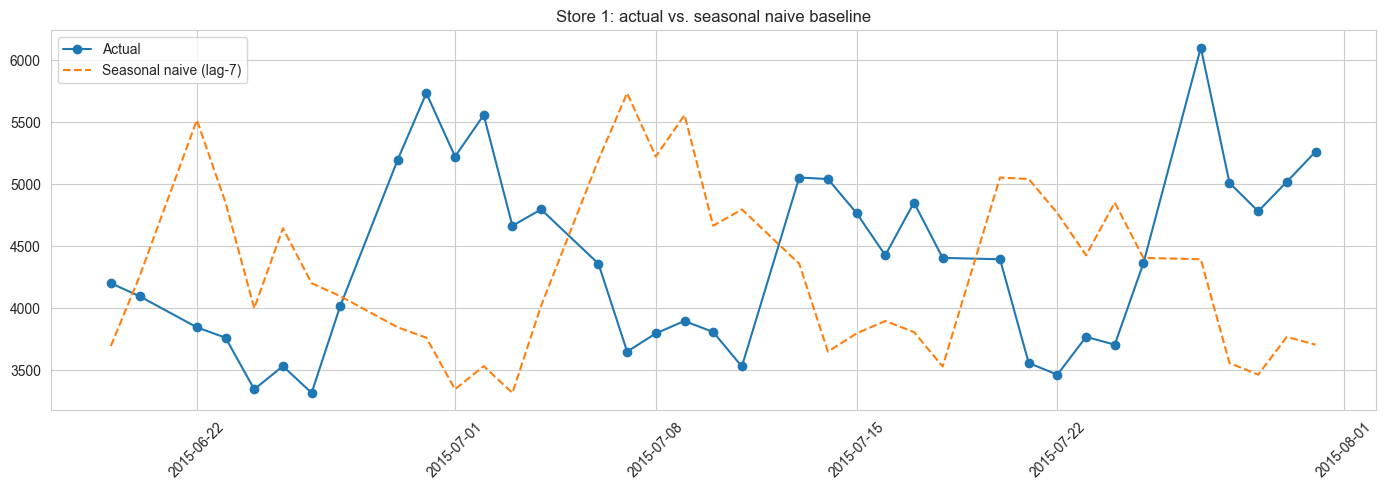

In [11]:
example_store = test_df['Store'].iloc[0]
store_test = test_df[test_df['Store'] == example_store].sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(store_test['Date'], store_test['Sales'], label='Actual', marker='o')
ax.plot(store_test['Date'], store_test['Sales_lag_7'], label='Seasonal naive (lag-7)', linestyle='--')
ax.set_title(f"Store {example_store}: actual vs. seasonal naive baseline")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Seasonal Naive lag-7 baseline tracks reasonably well to the this store; the baseline may be missing the promo or holidays the baseline can't know about

## 6. Summary
The random-vs-chronological split showed a difference of 4.0% between the two; the winning baseline is the Seasonal Naive (lag-7) with an RMSE of 2809.07, a MAE of 2178.00, and a MAPE of 31.82%. This baseline model also tracked reasonably well to the actual data for an example store. Becuase baselines can't use promo/holiday information at, I think either a statistic or ML model can improve metrics like RMSE & MAE relative to these baselines. </br>
Next: `03_statistical_model.ipynb` - Prophet or SARIMA, which should beat these baselines by explicitly modeling trend, seasonality, and holiday effects.